# Multi-Frame MAP vs Bradley-Terry MAP: A Rigorous Comparison

This notebook compares two **MAP-based** learning approaches under the multi-frame data generating process.
**No Bayesian posterior sampling. No BALD acquisition.** Both methods use MAP inference and MAP-consistent acquisition.

## A) Multi-Frame MAP Learner
- **DGP**: Uses `predict_response_noisy` with τ/τ' (4 outcome types)
- **Inference**: MAP estimation on simplex via SLSQP optimization
  - Uses full multi-frame likelihood over all 4 outcomes
  - L2 regularization for numerical stability
- **Acquisition**: Predictive entropy at ω_MAP:
  - `score(q) = H( p(·|q, ω_MAP) )` where p has 4 outcomes
  - This is NOT BALD (no posterior samples)

## B) Bradley-Terry MAP Baseline
- **Inference**: BT logistic MAP on simplex (uses only decisive left/right)
  - `p(left|ω,q) = sigmoid(ωᵀ φ(q))`, φ(q) = x_left - x_right
  - L2 regularization, ignores indifferent/incomparable for likelihood
- **Acquisition**: Fisher information style uncertainty:
  - `score(q) = p(1-p) * ||φ(q)||²` where p = sigmoid(ω_MAP^T φ(q))
  - Measures informativeness under BT model

## Key Difference from BALD Version
- **No MCMC sampling** for multi-frame
- **No Laplace approximation** for BT
- **Both use point estimates** (ω_MAP) for query selection
- **Acquisition is purely predictive**, not information-theoretic


In [35]:
# ============================================================================
# CELL 1: Imports, Constants, and Helper Utilities
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Constants
# ============================================================================
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)

# Default model parameters
TAU = 0.25           # Indifference threshold
TAU_PRIME = 0.25     # Incomparability threshold  
LAMBDA_X = 1.0       # Feature scaling

# ============================================================================
# Data Structures (from codebase)
# ============================================================================
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

# ============================================================================
# Helper Functions
# ============================================================================
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))."""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))

def phi(query: PairwiseQuery) -> np.ndarray:
    """Feature difference vector: x_left - x_right."""
    return query.patient_left.to_array() - query.patient_right.to_array()

def generate_random_patient_normalized() -> Patient:
    """Generate a random patient with features in [0, 1]."""
    return Patient(
        elderlyDep=np.random.uniform(0, 1),
        lifeYearsGained=np.random.uniform(0, 1),
        obesity=np.random.uniform(0, 1),
        weeklyWorkhours=np.random.uniform(0, 1),
        yearsWaiting=np.random.uniform(0, 1),
    )

def generate_candidate_queries(n_candidates: int = 100) -> List[PairwiseQuery]:
    """Generate candidate queries with normalized features."""
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized()
        right = generate_random_patient_normalized()
        candidates.append(PairwiseQuery(left, right))
    return candidates

print(f"Initialized with {DIM} features: {FEATURE_NAMES}")
print(f"Default thresholds: τ={TAU}, τ'={TAU_PRIME}")

Initialized with 5 features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
Default thresholds: τ=0.25, τ'=0.25


In [36]:
# ============================================================================
# CELL 2: Multi-Frame Model (DGP + Likelihood + Inference)
# ============================================================================
# These functions define the "true" multi-frame model used as the DGP
# and for Bayesian inference.
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active frames.
    Returns: (gaps array, set of active frame indices)
    """
    feature_diff = phi(query)
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score Δ(ω) and intensity r(ω).
    """
    delta_omega = float(np.dot(gaps, weights))
    r_omega = float(sum(weights[j] * abs(gaps[j]) for j in active_frames))
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0
) -> Callable:
    """
    Create noise function for latent margins.
    - Δ gets additive noise
    - r gets multiplicative noise (r̃ = r * exp(ε_r)) to stay positive
    """
    def noise_fn(delta: float, r: float) -> Tuple[float, float]:
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        return delta_tilde, r_tilde
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Generate response from multi-frame model with noise.
    Returns: 'left', 'right', 'indifferent', or 'incomparable'
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    delta_tilde, r_tilde = noise_fn(delta, r)
    
    if r_tilde < tau:
        return 'indifferent'
    if abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_prime * r_tilde else 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    Returns: [p_left, p_right, p_indifferent, p_incomparable]
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        
        if r_tilde < tau:
            counts['indifferent'] += 1
        elif abs(delta_tilde) < tau_prime * r_tilde:
            counts['incomparable'] += 1
        elif delta_tilde >= tau_prime * r_tilde:
            counts['left'] += 1
        else:
            counts['right'] += 1
    
    probs = np.array([counts['left'], counts['right'], 
                      counts['indifferent'], counts['incomparable']]) / n_mc_samples
    return probs


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
) -> float:
    """Compute total log-likelihood of transcript under multi-frame model."""
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


print("Multi-frame model functions defined:")
print("  - predict_response_noisy: DGP for generating responses")
print("  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo")
print("  - compute_transcript_log_likelihood: for MCMC")

Multi-frame model functions defined:
  - predict_response_noisy: DGP for generating responses
  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo
  - compute_transcript_log_likelihood: for MCMC


In [37]:
# ============================================================================
# CELL 3: Multi-Frame MAP Fitting
# ============================================================================
# Instead of MCMC posterior sampling, we fit MAP directly via optimization.
# ============================================================================
# ============================================================================
# CELL 3: Multi-Frame MCMC Sampler
# ============================================================================

def hit_and_run_simplex_step(x: np.ndarray) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    dim = len(x)
    d = np.random.randn(dim)
    d = d - d.mean()  # Project onto sum=0
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = np.random.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(ω | transcript) using hit-and-run + MH.
    Returns: (samples array, acceptance rate)
    """
    dim = DIM
    omega = np.ones(dim) / dim
    
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    samples = []
    n_accepted = 0
    
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega)
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        
        if np.log(np.random.rand()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in:
            samples.append(omega.copy())
    
    return np.array(samples), n_accepted / max(1, n_samples)


print("MCMC sampler defined: sample_posterior_hit_and_run")

# ============================================================================
# CELL 6: Multi-Frame BALD Query Selection
# ============================================================================
#
# BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
#
# Uses the full 4-outcome distribution from compute_response_probs_mc.
# This is the multi-frame model's query selection strategy.
# ============================================================================

def multiframe_bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
) -> float:
    """
    Compute BALD score for a query using full 4-outcome model.
    
    BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
    """
    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def multiframe_select_query(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
) -> PairwiseQuery:
    """Select best query according to multi-frame BALD."""
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = multiframe_bald_score(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V
        )
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("Multi-frame BALD functions defined:")
print("  - multiframe_bald_score: BALD over 4 outcomes")
print("  - multiframe_select_query: selects best BALD query")

def run_multiframe_trial(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    seed: int = None,
) -> Dict:
    """
    Run one multi-frame active learning trial.
    
    This is the "true model":
    - Query selection: BALD over full 4 outcomes
    - Inference: Bayesian posterior via MCMC with multi-frame likelihood
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    
    cos_sims = []
    n_decisive_list = []
    responses = Counter()
    
    # Initial uniform prior samples
    posterior_samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using multi-frame BALD
        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x
        )
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        # Update posterior
        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
        )
        
        # Posterior mean as point estimate
        omega_hat = posterior_samples.mean(axis=0)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'final_estimate': posterior_samples.mean(axis=0),
    }



MCMC sampler defined: sample_posterior_hit_and_run
Multi-frame BALD functions defined:
  - multiframe_bald_score: BALD over 4 outcomes
  - multiframe_select_query: selects best BALD query


In [38]:
# ============================================================================
# CELL 6: BT MAP Trial Runners with Rejection Memory
# ============================================================================
# Pure MAP inference + Fisher info acquisition + rejection memory.
# 
# Rejection Memory:
#   When BT receives non-decisive (indifferent/incomparable), it stores the
#   query signature (normalized phi). Future query scores are penalized by:
#     penalty = 1 - avoid_strength * max_abs_cos_sim(sig(q), rejected_sigs)
#   Using abs() handles flipped queries (q vs -q represent same comparison).
# ============================================================================


def fit_bt_map_simplex(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
    warm_start: np.ndarray = None,
) -> np.ndarray:
    """
    Fit BT MAP estimate under simplex constraints.
    
    Args:
        phis: (N, dim) array of feature differences φ(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength
        n_restarts: Number of random restarts
        warm_start: Initial point for optimization
    
    Returns:
        omega_map: MAP estimate on simplex
    """
    if len(phis) == 0:
        return np.ones(dim) / dim
    
    def neg_log_posterior(omega):
        logits = phis @ omega
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]
    
    # Collect starting points
    starting_points = []
    if warm_start is not None:
        starting_points.append(warm_start)
    for _ in range(n_restarts):
        starting_points.append(np.random.dirichlet(np.ones(dim)))
    
    best_result = None
    for omega0 in starting_points:
        try:
            result = minimize(
                neg_log_posterior, omega0, method='SLSQP',
                bounds=bounds, constraints=constraints,
                options={'maxiter': 500, 'ftol': 1e-8}
            )
            if best_result is None or result.fun < best_result.fun:
                best_result = result
        except Exception:
            continue
    
    if best_result is None:
        return np.ones(dim) / dim
    
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


def query_signature(query: PairwiseQuery) -> Optional[np.ndarray]:
    """
    Compute query signature for rejection memory.
    Returns normalized phi vector (unit norm), or None if near-zero norm.
    
    Safety: Returns None for near-zero norm queries to avoid storing
    degenerate signatures that could cause numerical issues.
    """
    phi_vec = phi(query)
    norm = np.linalg.norm(phi_vec)
    if norm < 1e-12:
        return None  # Near-zero norm - don't store
    return phi_vec / norm


def rejection_penalty(
    sig: np.ndarray,
    rejected_signatures: List[np.ndarray],
    avoid_strength: float = 0.5,
) -> float:
    """
    Compute rejection avoidance penalty for a query signature.
    
    penalty = 1 - avoid_strength * max_abs_cos_sim(sig, rejected_sigs)
    
    Uses absolute cosine similarity to handle flipped queries:
    q and -q represent the same comparison (left vs right swapped),
    so we want to penalize both equally.
    
    Args:
        sig: Normalized query signature (unit norm)
        rejected_signatures: List of normalized rejected query signatures
        avoid_strength: How strongly to avoid rejected queries (0-1)
    
    Returns:
        Penalty value in [1-avoid_strength, 1]. Lower = more similar to rejected.
    """
    if len(rejected_signatures) == 0:
        return 1.0
    
    if sig is None:
        # Near-zero norm query - return full penalty (avoid it)
        return 1.0 - avoid_strength
    
    # Compute max absolute cosine similarity to rejected queries
    max_cos_sim = 0.0
    for rej_sig in rejected_signatures:
        cos_sim = abs(np.dot(sig, rej_sig))  # Use abs() for flipped queries
        max_cos_sim = max(max_cos_sim, cos_sim)
    
    # Compute penalty and clip to [0, 1]
    penalty = 1.0 - avoid_strength * max_cos_sim
    penalty = np.clip(penalty, 0.0, 1.0)
    
    return penalty


def bt_map_fisher_score_with_rejection(
    query: PairwiseQuery,
    omega_map: np.ndarray,
    rejected_signatures: List[np.ndarray],
    avoid_strength: float = 0.5,
) -> float:
    """
    Compute Fisher info score with rejection penalty.
    
    score(q) = p(1-p) * ||φ(q)||² * rejection_penalty(q)
    
    The penalty discourages queries similar to previously rejected ones.
    """
    phi_vec = phi(query)
    logit = np.dot(omega_map, phi_vec)
    p = sigmoid(logit)
    
    # Fisher info component
    variance = p * (1 - p)
    phi_norm_sq = np.dot(phi_vec, phi_vec)
    fisher_score = variance * phi_norm_sq
    
    # Get normalized signature for penalty computation
    sig = query_signature(query)
    penalty = rejection_penalty(sig, rejected_signatures, avoid_strength)
    
    return fisher_score * penalty


def bt_select_query_map_fisher(
    candidates: List[PairwiseQuery],
    omega_map: np.ndarray,
    rejected_signatures: List[np.ndarray] = None,
    avoid_strength: float = 0.5,
) -> PairwiseQuery:
    """
    Select query with highest Fisher info score (with rejection penalty).
    
    Args:
        candidates: List of candidate queries
        omega_map: Current MAP estimate
        rejected_signatures: Signatures of previously rejected queries
        avoid_strength: How strongly to avoid rejected queries (0-1)
    """
    if rejected_signatures is None:
        rejected_signatures = []
    
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = bt_map_fisher_score_with_rejection(
            query, omega_map, rejected_signatures, avoid_strength
        )
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


def run_bt_trial_map(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    forced_choice: Optional[str] = None,
    n_candidates: int = 100,
    l2_reg: float = 1e-2,
    avoid_strength: float = 0.5,
    seed: int = None,
) -> Dict:
    """
    Run BT trial with MAP inference + Fisher info acquisition + rejection memory.
    
    Rejection Memory:
        When receiving non-decisive responses, stores query signature (normalized phi).
        Future query scores are penalized based on similarity to rejected queries.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_fn: Noise function for DGP
        tau, tau_prime: DGP thresholds (BT doesn't use these internally)
        lambda_x: Feature scaling
        n_attempts: Number of queries to make
        forced_choice: How to handle non-decisive responses:
            - None: Ignore non-decisive for inference, add to rejection memory
            - "random": Force to random left/right, NO rejection memory
            - "left": Force to left, NO rejection memory
        n_candidates: Candidate queries per round
        l2_reg: L2 regularization for MAP
        avoid_strength: How strongly to avoid rejected queries (0-1)
        seed: Random seed
    
    Returns:
        Dict with cos_sims, responses, n_decisive, n_rejected, etc.
    """
    rng = np.random.default_rng(seed)
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    
    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []
    rejected_signatures = []  # Rejection memory
    
    cos_sims = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    n_rejected = 0
    
    # Initial estimate: uniform
    omega_map = np.ones(dim) / dim
    
    for t in range(n_attempts):
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using Fisher info with rejection penalty
        best_query = bt_select_query_map_fisher(
            candidates, omega_map, rejected_signatures, avoid_strength
        )
        
        # Query oracle (using multi-frame DGP)
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        
        # Handle response based on forced_choice mode
        if raw_response in ('left', 'right'):
            # Naturally decisive - use for inference
            response = raw_response
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            
        elif forced_choice is None:
            # No forcing - add to rejection memory, don't use for inference
            response = raw_response
            sig = query_signature(best_query)
            if sig is not None:  # Only store if valid (non-zero norm)
                rejected_signatures.append(sig)
            n_rejected += 1
            
        elif forced_choice == "random":
            # Force to random - use for inference, NO rejection memory
            response = "left" if rng.random() < 0.5 else "right"
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            n_forced += 1
            
        elif forced_choice == "left":
            # Force to left - use for inference, NO rejection memory
            response = "left"
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0)
            n_forced += 1
            
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")
        
        forced_responses[response] += 1
        
        # Fit MAP (warm start)
        if len(phis_decisive) > 0:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            omega_map = fit_bt_map_simplex(
                phis_arr, ys_arr, dim, l2_reg,
                warm_start=omega_map
            )
        else:
            omega_map = np.ones(dim) / dim
        
        cos_sims.append(cosine_similarity(omega_map, oracle_weights))
    
    return {
        'cos_sims': cos_sims,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'n_rejected': n_rejected,
        'final_estimate': omega_map,
    }


def run_bt_trial_map_until_k(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    k_decisive: int,
    forced_choice: Optional[str] = None,
    max_attempts: int = 500,
    n_candidates: int = 100,
    l2_reg: float = 1e-2,
    avoid_strength: float = 0.5,
    seed: int = None,
) -> Dict:
    """
    Run BT MAP trial until k decisive responses are collected.
    Includes rejection memory for non-decisive responses.
    
    Args:
        k_decisive: Target number of decisive responses
        max_attempts: Maximum queries before giving up
        avoid_strength: Rejection avoidance strength (0-1)
        (other args same as run_bt_trial_map)
    
    Returns:
        Dict with cos_sims, n_attempts, n_decisive, n_rejected, etc.
    """
    rng = np.random.default_rng(seed)
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    
    transcript = []
    phis_decisive = []
    ys_decisive = []
    rejected_signatures = []
    
    cos_sims = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    n_rejected = 0
    
    omega_map = np.ones(dim) / dim
    
    attempt = 0
    while len(phis_decisive) < k_decisive and attempt < max_attempts:
        attempt += 1
        
        candidates = generate_candidate_queries(n_candidates)
        best_query = bt_select_query_map_fisher(
            candidates, omega_map, rejected_signatures, avoid_strength
        )
        
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        
        if raw_response in ('left', 'right'):
            response = raw_response
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            
        elif forced_choice is None:
            response = raw_response
            sig = query_signature(best_query)
            if sig is not None:  # Only store if valid (non-zero norm)
                rejected_signatures.append(sig)
            n_rejected += 1
            
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            n_forced += 1
            
        elif forced_choice == "left":
            response = "left"
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0)
            n_forced += 1
            
        else:
            raise ValueError(f"Unknown forced_choice: {forced_choice}")
        
        forced_responses[response] += 1
        
        if len(phis_decisive) > 0:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            omega_map = fit_bt_map_simplex(
                phis_arr, ys_arr, dim, l2_reg,
                warm_start=omega_map
            )
        else:
            omega_map = np.ones(dim) / dim
        
        cos_sims.append(cosine_similarity(omega_map, oracle_weights))
    
    return {
        'cos_sims': cos_sims,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'n_rejected': n_rejected,
        'n_attempts': attempt,
        'reached_k': len(phis_decisive) >= k_decisive,
        'final_estimate': omega_map,
    }


print("BT MAP trial runners with rejection memory defined:")
print("  - query_signature: normalized phi for rejection memory (returns None if near-zero)")
print("  - rejection_penalty: 1 - avoid_strength * max_abs_cos_sim (uses abs for flipped queries)")
print("  - bt_map_fisher_score_with_rejection: Fisher * penalty")
print("  - bt_select_query_map_fisher: selects query with rejection avoidance")
print("  - run_bt_trial_map: fixed attempts, with rejection memory")
print("  - run_bt_trial_map_until_k: until k decisive, with rejection memory")
print("  Defaults: n_candidates=100, l2_reg=1e-2, avoid_strength=0.5")

BT MAP trial runners with rejection memory defined:
  - query_signature: normalized phi for rejection memory (returns None if near-zero)
  - rejection_penalty: 1 - avoid_strength * max_abs_cos_sim (uses abs for flipped queries)
  - bt_map_fisher_score_with_rejection: Fisher * penalty
  - bt_select_query_map_fisher: selects query with rejection avoidance
  - run_bt_trial_map: fixed attempts, with rejection memory
  - run_bt_trial_map_until_k: until k decisive, with rejection memory
  Defaults: n_candidates=100, l2_reg=1e-2, avoid_strength=0.5


# Grid Sweep Experiments

Compare **Multi-frame MAP** vs **BT MAP** across (τ, τ') grid.

Both use:
- MAP inference (no Bayesian posterior sampling)
- MAP-consistent acquisition (no BALD)


In [39]:
# ============================================================================
# CELL 8: Grid Sweep - Helper Functions (MAP Version)
# ============================================================================

from typing import Dict, Any, Optional
import time

def average_curves(results_list: List[Dict], key: str = 'cos_sims', T: int = None) -> Dict:
    """
    Average cosine similarity curves across multiple trial results.
    """
    curves = []
    for r in results_list:
        curve = np.array(r[key])
        curves.append(curve)
    
    if T is None:
        T = min(len(c) for c in curves) if curves else 0
    
    padded = []
    for c in curves:
        if len(c) >= T:
            padded.append(c[:T])
        else:
            pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
            pad[:len(c)] = c
            padded.append(pad)
    
    raw = np.array(padded)
    mean = raw.mean(axis=0)
    stderr = raw.std(axis=0) / np.sqrt(len(raw)) if len(raw) > 0 else np.zeros_like(mean)
    
    return {'mean': mean, 'stderr': stderr, 'raw': raw}


def make_fixed_oracle_set(N: int, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 1) -> List[np.ndarray]:
    """
    Create fixed oracle set with sparse Dirichlet weights.
    """
    rng = np.random.default_rng(oracle_seed)
    return [rng.dirichlet(alpha * np.ones(dim)) for _ in range(N)]


def run_cell_experiment(
    tau: float,
    tau_prime: float,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    lambda_x: float,
    T: int,
    oracle_weights_list: List[np.ndarray],
    n_candidates: int = 100,
    l2_reg: float = 1e-2,
    n_mc_samples: int = 100,
    avoid_strength: float = 0.5,
    base_seed: int = 0,
    methods: List[str] = None,
    k_decisive: int = None,
) -> Dict[str, Dict]:
    """
    Run MAP experiment for a single (tau, tau_prime) cell.
    
    Uses MAP methods (no Bayesian posterior sampling):
    - multiframe_bald: Multi-frame BALD
    - bt_map: BT MAP + Fisher info + rejection memory
    - bt_map_k: BT MAP until k decisive + rejection memory
    - bt_map_random: BT MAP + random forced choice (no rejection memory)
    - bt_map_left: BT MAP + deterministic left (no rejection memory)
    
    Args:
        avoid_strength: How strongly BT avoids rejected queries (0-1)
    """
    if methods is None:
        methods = ['multiframe_bald', 'bt_map']
    
    if k_decisive is None:
        k_decisive = T
    
    N = len(oracle_weights_list)
    
    method_trials = {m: [] for m in methods}
    method_responses = {m: Counter() for m in methods}
    method_extras = {m: {'n_forced': 0, 'n_attempts': 0, 'n_decisive': 0, 'n_rejected': 0} for m in methods}
    
    for trial in range(N):
        trial_seed = base_seed + trial
        oracle_weights = oracle_weights_list[trial]
        
        for method_index, method in enumerate(methods):
            method_seed = trial_seed + method_index * 100_000
            noise_fn = create_noise_fn(noise_type, scale_delta, scale_r)
            
            if method == 'multiframe_bald':
                result = run_multiframe_trial(
                    oracle_weights, noise_fn, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                     seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']
                
            elif method == 'bt_map':
                result = run_bt_trial_map(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice=None, n_candidates=n_candidates,
                    l2_reg=l2_reg, avoid_strength=avoid_strength, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['n_decisive']
                method_extras[method]['n_rejected'] += result['n_rejected']
                
            elif method == 'bt_map_k':
                result = run_bt_trial_map_until_k(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    k_decisive=k_decisive, forced_choice=None,
                    n_candidates=n_candidates, l2_reg=l2_reg,
                    avoid_strength=avoid_strength, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_attempts'] += result['n_attempts']
                method_extras[method]['n_decisive'] += result['n_decisive']
                method_extras[method]['n_rejected'] += result['n_rejected']
                
            elif method == 'bt_map_random':
                result = run_bt_trial_map(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice="random", n_candidates=n_candidates,
                    l2_reg=l2_reg, avoid_strength=avoid_strength, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_map_left':
                result = run_bt_trial_map(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice="left", n_candidates=n_candidates,
                    l2_reg=l2_reg, avoid_strength=avoid_strength, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']
    
    # Aggregate results
    results = {}
    for method in methods:
        if method == 'bt_map_k':
            avg = average_curves(method_trials[method], key='cos_sims', T=k_decisive)
        else:
            avg = average_curves(method_trials[method], key='cos_sims', T=T)
        avg['response_counts'] = method_responses[method]
        avg['extras'] = method_extras[method]
        avg['trial_results'] = method_trials[method]
        results[method] = avg
    
    return results


print("Grid sweep helpers defined (MAP version with rejection memory):")
print("  - average_curves, make_fixed_oracle_set, run_cell_experiment")
print("  Available methods: multiframe_bald, bt_map, bt_map_k, bt_map_random, bt_map_left")
print("  Defaults: n_candidates=100, l2_reg=1e-2, avoid_strength=0.5")

Grid sweep helpers defined (MAP version with rejection memory):
  - average_curves, make_fixed_oracle_set, run_cell_experiment
  Available methods: multiframe_bald, bt_map, bt_map_k, bt_map_random, bt_map_left
  Defaults: n_candidates=100, l2_reg=1e-2, avoid_strength=0.5


In [40]:
# ============================================================================
# Sanity Check: Verify Oracle Set Properties (Same for MAP and Bayesian)
# ============================================================================

def check_oracle_set(N: int = 3, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 1):
    """Print statistics about the oracle set to verify it's properly sparse."""
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=alpha)
    
    uniform = np.ones(dim) / dim
    cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
    max_weights = [np.max(w) for w in oracle_weights_list]
    
    print(f"Oracle Set Properties (N={N}, dim={dim}, alpha={alpha}, seed={oracle_seed})")
    print("=" * 60)
    print(f"Baseline cosine similarity (vs uniform):")
    print(f"  Mean: {np.mean(cos_baselines):.4f}")
    print(f"  Min:  {np.min(cos_baselines):.4f}")
    print(f"  Max:  {np.max(cos_baselines):.4f}")
    print()
    print(f"Max weight per oracle (measures peakiness):")
    print(f"  Mean: {np.mean(max_weights):.4f}")
    print(f"  Min:  {np.min(max_weights):.4f}")
    print(f"  Max:  {np.max(max_weights):.4f}")
    print()
    print("Sample oracles (first 3):")
    for i, w in enumerate(oracle_weights_list[:3]):
        print(f"  Oracle {i}: {np.round(w, 3)}")
    print()
    
    if np.mean(cos_baselines) < 0.7:
        print("✓ Oracles are sparse - cosine has room to improve!")
    else:
        print("⚠ Oracles may not be sparse enough - consider lower alpha")
    
    return oracle_weights_list


# Run the check
print("Checking oracle set (alpha=0.2):")
_ = check_oracle_set(N=3, alpha=0.2)


Checking oracle set (alpha=0.2):
Oracle Set Properties (N=3, dim=5, alpha=0.2, seed=2026)
Baseline cosine similarity (vs uniform):
  Mean: 0.5753
  Min:  0.4776
  Max:  0.7549

Max weight per oracle (measures peakiness):
  Mean: 0.7860
  Min:  0.5192
  Max:  0.9348

Sample oracles (first 3):
  Oracle 0: [0.    0.01  0.003 0.053 0.935]
  Oracle 1: [0.519 0.181 0.091 0.008 0.201]
  Oracle 2: [0.05  0.001 0.044 0.001 0.904]

✓ Oracles are sparse - cosine has room to improve!


In [41]:
# ============================================================================
# CELL 10: Grid Sweep - Main Function (MAP Version)
# ============================================================================

def run_grid_sweep(
    taus: List[float],
    tau_primes: List[float],
    dim: int = DIM,
    T: int = 20,
    N: int = 3,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    lambda_x: float = 1.0,
    n_candidates: int = 100,
    l2_reg: float = 1e-2,
    n_mc_samples: int = 100,
    avoid_strength: float = 0.5,
    methods: List[str] = None,
    k_decisive: int = None,
    seed: int = 42,
    oracle_seed: int = 2026,
    oracle_alpha: float = 1,
    verbose: bool = True,
) -> Dict[tuple, Dict[str, Dict]]:
    """
    Run MAP grid sweep over (tau, tau_prime) pairs.
    
    Uses MAP methods (no Bayesian inference):
    - multiframe_bald: Multi-frame BALD
    - bt_map: BT MAP + Fisher info + rejection memory
    - bt_map_k, bt_map_random, bt_map_left: BT variants
    
    Args:
        avoid_strength: How strongly BT avoids rejected queries (0-1)
    """
    if methods is None:
        methods = ['multiframe_bald', 'bt_map']
    
    if k_decisive is None:
        k_decisive = T
    
    # Create fixed oracle set ONCE
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=oracle_alpha)
    
    if verbose:
        uniform = np.ones(dim) / dim
        cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
        max_weights = [np.max(w) for w in oracle_weights_list]
        print(f"Fixed oracle set (N={N}, alpha={oracle_alpha}, seed={oracle_seed}):")
        print(f"  Baseline cos_sim (uniform): mean={np.mean(cos_baselines):.3f}")
        print(f"  Max oracle weight: mean={np.mean(max_weights):.3f}")
        print(f"  BT rejection avoidance: avoid_strength={avoid_strength}")
        print()
    
    results = {}
    total_cells = len(taus) * len(tau_primes)
    cell_idx = 0
    start_time = time.time()
    
    short_names = {
        'multiframe_bald': 'MF-BALD',
        'bt_map': 'BT-MAP',
        'bt_map_k': 'BT-K',
        'bt_map_random': 'BT-R',
        'bt_map_left': 'BT-L',
    }
    
    for tau in taus:
        for tau_prime in tau_primes:
            cell_idx += 1
            
            if verbose:
                elapsed = time.time() - start_time
                print(f"[{cell_idx}/{total_cells}] τ={tau:.1f}, τ'={tau_prime:.1f} ... ", end='', flush=True)
            
            cell_result = run_cell_experiment(
                tau, tau_prime, noise_type, scale_delta, scale_r,
                lambda_x, T, oracle_weights_list, n_candidates,
                l2_reg=l2_reg, n_mc_samples=n_mc_samples,
                avoid_strength=avoid_strength,
                base_seed=seed, methods=methods, k_decisive=k_decisive
            )
            
            results[(tau, tau_prime)] = cell_result
            
            if verbose:
                parts = []
                for m in methods:
                    if m in cell_result:
                        final_cos = cell_result[m]['mean'][-1]
                        parts.append(f"{short_names.get(m, m)}={final_cos:.3f}")
                print(", ".join(parts))
    
    if verbose:
        total_time = time.time() - start_time
        print(f"\nTotal time: {total_time:.1f}s")
    
    return results


print("Grid sweep main function defined: run_grid_sweep (MAP version with rejection memory)")
print("  Defaults: n_candidates=100, l2_reg=1e-2, avoid_strength=0.5")

Grid sweep main function defined: run_grid_sweep (MAP version with rejection memory)
  Defaults: n_candidates=100, l2_reg=1e-2, avoid_strength=0.5


In [42]:
# ============================================================================
# CELL 11: Grid Sweep - Plotting Function (MAP Version)
# ============================================================================

def plot_grid_sweep(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    methods_to_plot: List[str] = None,
    method_colors: Dict[str, str] = None,
    method_labels: Dict[str, str] = None,
    figsize_per_cell: tuple = (1.2, 1.0),
    show_stderr: bool = False,
    save_path: str = None,
):
    """
    Plot grid of convergence curves for MAP methods.
    """
    if methods_to_plot is None:
        first_key = list(results.keys())[0]
        methods_to_plot = list(results[first_key].keys())
    
    if method_colors is None:
        method_colors = {
            'multiframe_bald': '#4477AA',
            'bt_map': '#EE6677',
            'bt_map_random': '#228833',
            'bt_map_left': '#CCBB44',
            'bt_map_k': '#AA3377',
        }
    
    if method_labels is None:
        method_labels = {
            'multiframe_bald': 'MF-MAP',
            'bt_map': 'BT-MAP',
            'bt_map_random': 'BT-R',
            'bt_map_left': 'BT-L',
            'bt_map_k': 'BT-K',
        }
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    fig_width = figsize_per_cell[0] * n_cols + 1.5
    fig_height = figsize_per_cell[1] * n_rows + 1.0
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                              sharex=True, sharey=True)
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    attempts = np.arange(1, T + 1)
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            ax = axes[i, j]
            cell_results = results.get((tau, tau_prime), {})
            
            for method in methods_to_plot:
                if method not in cell_results:
                    continue
                
                data = cell_results[method]
                mean = data['mean']
                color = method_colors.get(method, 'black')
                label = method_labels.get(method, method)
                
                ax.plot(attempts[:len(mean)], mean, '-', color=color,
                        linewidth=1.0, label=label)
                
                if show_stderr and 'stderr' in data:
                    stderr = data['stderr']
                    ax.fill_between(attempts[:len(mean)],
                                    mean - stderr, mean + stderr,
                                    color=color, alpha=0.2)
            
            ax.set_ylim(0.3, 1.0)
            if i == 0:
                ax.set_title(f'τ={tau}')
            if j == 0:
                ax.set_ylabel(f"τ'={tau_prime}")
    
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(methods_to_plot),
               bbox_to_anchor=(0.5, 0.02))
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


print("Plot function defined: plot_grid_sweep (MAP version)")


Plot function defined: plot_grid_sweep (MAP version)


In [43]:
# ============================================================================
# CELL 12: Final Grid Sweep - All MAP Methods with Data Export
# ============================================================================

import pandas as pd
import pickle
from datetime import datetime

def run_final_grid_sweep_to_csv(
    taus: List[float] = [0.0, 0.2, 0.4],
    tau_primes: List[float] = [0.0, 0.2],
    T: int = 50,
    N: int = 5,
    k_decisive: int = None,
    output_prefix: str = "map_grid_sweep_results",
    oracle_seed: int = 2026,
    oracle_alpha: float = 1,
    save_pickle: bool = True,
    **kwargs
) -> tuple:
    """
    Run final MAP grid sweep with all methods and save data.
    
    Methods tested (all MAP-based, no Bayesian):
        1. multiframe_bald: MF BALD
        2. bt_map: BT MAP + Fisher info (skips non-decisive)
        3. bt_map_k: BT MAP until k decisive
        4. bt_map_random: BT MAP + random forced choice
        5. bt_map_left: BT MAP + deterministic left
    """
    if k_decisive is None:
        k_decisive = T
    
    methods = [
        'multiframe_bald',
        'bt_map',
        'bt_map_k',
        'bt_map_random',
        'bt_map_left',
    ]
    
    print("=" * 70)
    print("FINAL MAP GRID SWEEP - 5 Methods Comparison")
    print("=" * 70)
    print(f"Methods: {methods}")
    print(f"Grid: {len(taus)} x {len(tau_primes)} = {len(taus) * len(tau_primes)} cells")
    print(f"T={T} attempts, N={N} trials, k_decisive={k_decisive}")
    print(f"Oracle: seed={oracle_seed}, alpha={oracle_alpha}")
    print("=" * 70)
    print()
    
    results = run_grid_sweep(
        taus=taus,
        tau_primes=tau_primes,
        T=T,
        N=N,
        methods=methods,
        k_decisive=k_decisive,
        oracle_seed=oracle_seed,
        oracle_alpha=oracle_alpha,
        **kwargs
    )
    
    # Create timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Build trials DataFrame
    rows = []
    for (tau, tau_prime), cell_results in results.items():
        for method, data in cell_results.items():
            for trial_idx, trial_result in enumerate(data['trial_results']):
                for t, cos_sim in enumerate(trial_result['cos_sims']):
                    rows.append({
                        'tau': tau,
                        'tau_prime': tau_prime,
                        'method': method,
                        'trial': trial_idx,
                        'attempt': t + 1,
                        'cos_sim': cos_sim,
                    })
    
    trials_df = pd.DataFrame(rows)
    
    # Build summary DataFrame
    summary_rows = []
    for (tau, tau_prime), cell_results in results.items():
        for method, data in cell_results.items():
            summary_rows.append({
                'tau': tau,
                'tau_prime': tau_prime,
                'method': method,
                'final_cos_mean': data['mean'][-1],
                'final_cos_stderr': data['stderr'][-1],
                'n_decisive': data['extras']['n_decisive'],
            })
    
    summary_df = pd.DataFrame(summary_rows)
    
    # Save files
    trials_path = f"{output_prefix}_trials_{timestamp}.csv"
    summary_path = f"{output_prefix}_summary_{timestamp}.csv"
    trials_df.to_csv(trials_path, index=False)
    summary_df.to_csv(summary_path, index=False)
    print(f"\nSaved: {trials_path}")
    print(f"Saved: {summary_path}")
    
    if save_pickle:
        pkl_path = f"{output_prefix}_{timestamp}.pkl"
        with open(pkl_path, 'wb') as f:
            pickle.dump({
                'results': results,
                'taus': taus,
                'tau_primes': tau_primes,
                'T': T,
                'N': N,
                'methods': methods,
            }, f)
        print(f"Saved: {pkl_path}")
    
    return results, trials_df, summary_df


def load_results_from_pickle(path: str):
    """Load results from pickle file."""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data['results'], data


print("Final grid sweep export defined: run_final_grid_sweep_to_csv (MAP version)")


Final grid sweep export defined: run_final_grid_sweep_to_csv (MAP version)


In [44]:
# ============================================================================
# CELL 13: Grid Convergence Curve Plots - MAP Version
# ============================================================================

def plot_4_convergence_grids(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    save_prefix: str = None,
    show_stderr: bool = True,
    figsize_per_cell: tuple = (1.2, 1.0),
):
    """
    Create 4 grid plots of convergence curves: MF-MAP vs each BT-MAP variant.
    """
    bt_methods = [
        ('bt_map', 'BT-MAP (Skips)', '#EE6677'),
        ('bt_map_k', 'BT-MAP (K-Decisive)', '#228833'),
        ('bt_map_random', 'BT-MAP (Random FC)', '#CCBB44'),
        ('bt_map_left', 'BT-MAP (Left FC)', '#AA3377'),
    ]
    
    import matplotlib
    matplotlib.rcParams['text.usetex'] = False
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
    
    sample_cell = list(results.values())[0]
    available_bt = [(m, l, c) for m, l, c in bt_methods if m in sample_cell]
    
    if 'multiframe_bald' not in sample_cell:
        print("ERROR: multiframe_bald not found in results")
        return
    
    print(f"Creating {len(available_bt)} convergence grid plots (MAP version)...")
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    for bt_method, bt_label, bt_color in available_bt:
        print(f"  Plotting: MF-MAP vs {bt_label}...")
        
        fig_width = figsize_per_cell[0] * n_cols + 1.5
        fig_height = figsize_per_cell[1] * n_rows + 1.2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                                  sharex=True, sharey=True)
        
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        if n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        attempts = np.arange(1, T + 1)
        
        for i, tau_prime in enumerate(tau_primes):
            for j, tau in enumerate(taus):
                ax = axes[n_rows - 1 - i, j]  # Flip so τ' increases upward
                cell_results = results.get((tau, tau_prime), {})
                
                # Plot Multiframe MAP
                if 'multiframe_bald' in cell_results:
                    mf_data = cell_results['multiframe_bald']
                    mf_mean = mf_data['mean']
                    ax.plot(attempts[:len(mf_mean)], mf_mean, '-', color='#4477AA',
                            linewidth=1.0, label='MF-MAP')
                    if show_stderr:
                        mf_stderr = mf_data['stderr']
                        ax.fill_between(attempts[:len(mf_mean)],
                                        mf_mean - mf_stderr, mf_mean + mf_stderr,
                                        color='#4477AA', alpha=0.2)
                
                # Plot BT method
                if bt_method in cell_results:
                    bt_data = cell_results[bt_method]
                    bt_mean = bt_data['mean']
                    ax.plot(attempts[:len(bt_mean)], bt_mean, '--', color=bt_color,
                            linewidth=1.0, label=bt_label.split('(')[0].strip())
                    if show_stderr:
                        bt_stderr = bt_data['stderr']
                        ax.fill_between(attempts[:len(bt_mean)],
                                        bt_mean - bt_stderr, bt_mean + bt_stderr,
                                        color=bt_color, alpha=0.2)
                
                ax.set_ylim(0, 1.0)
                ax.set_xlim(1, T)
                
                if i == 0:
                    ax.set_xlabel(f'τ={tau}')
                if j == 0:
                    ax.set_ylabel(f"τ'={tau_prime}")
        
        # Add legend
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=2,
                   bbox_to_anchor=(0.5, 0.02), frameon=False)
        
        fig.suptitle(f'MF-MAP vs {bt_label}', y=1.02)
        plt.tight_layout()
        
        if save_prefix:
            fig.savefig(f'{save_prefix}_mf_vs_{bt_method}.pdf', bbox_inches='tight')
            print(f"    Saved: {save_prefix}_mf_vs_{bt_method}.pdf")
        
        plt.show()


print("Plotting function defined: plot_4_convergence_grids (MAP version)")


Plotting function defined: plot_4_convergence_grids (MAP version)


In [45]:
# ============================================================================
# RUN: Execute Final MAP Grid Sweep
# ============================================================================

# --- Run new MAP experiment ---
results, trials_df, summary_df = run_final_grid_sweep_to_csv(
    taus=[0.0, 0.2, 0.4],
    tau_primes=[0.0, 0.2],
    T=50,
    N=3,
    k_decisive=50,
    n_candidates=50,
    l2_reg=1.0,
    n_mc_samples=100,
    seed=42,
    output_prefix="map_grid_sweep_5methods"
)


FINAL MAP GRID SWEEP - 5 Methods Comparison
Methods: ['multiframe_bald', 'bt_map', 'bt_map_k', 'bt_map_random', 'bt_map_left']
Grid: 3 x 2 = 6 cells
T=50 attempts, N=3 trials, k_decisive=50
Oracle: seed=2026, alpha=1

Fixed oracle set (N=3, alpha=1, seed=2026):
  Baseline cos_sim (uniform): mean=0.852
  Max oracle weight: mean=0.373
  BT rejection avoidance: avoid_strength=0.5

[1/6] τ=0.0, τ'=0.0 ... MF-BALD=0.883, BT-MAP=0.594, BT-K=0.546, BT-R=0.861, BT-L=0.570
[2/6] τ=0.0, τ'=0.2 ... MF-BALD=0.841, BT-MAP=0.490, BT-K=0.587, BT-R=0.893, BT-L=0.609
[3/6] τ=0.2, τ'=0.0 ... 

KeyboardInterrupt: 

Creating 4 convergence grid plots (MAP version)...
  Plotting: MF-MAP vs BT-MAP (Skips)...
    Saved: map_convergence_grid_mf_vs_bt_map.pdf


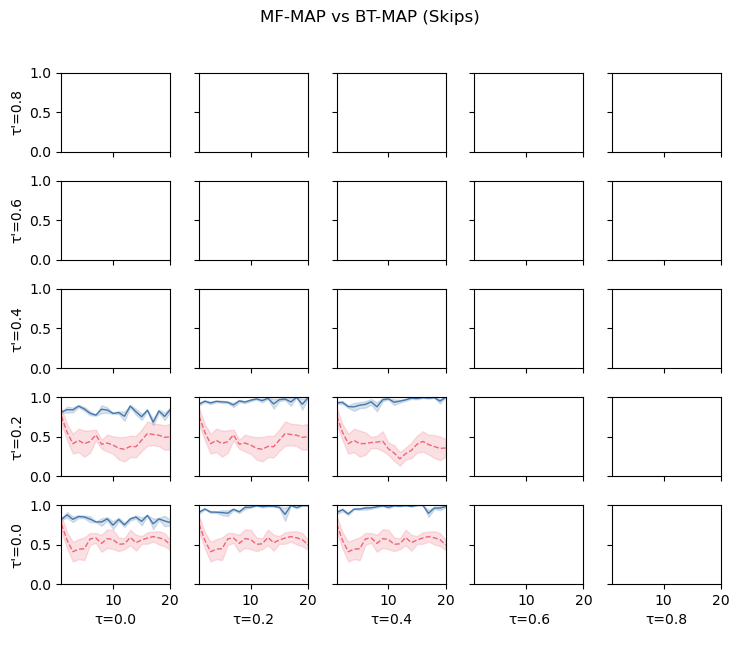

  Plotting: MF-MAP vs BT-MAP (K-Decisive)...
    Saved: map_convergence_grid_mf_vs_bt_map_k.pdf


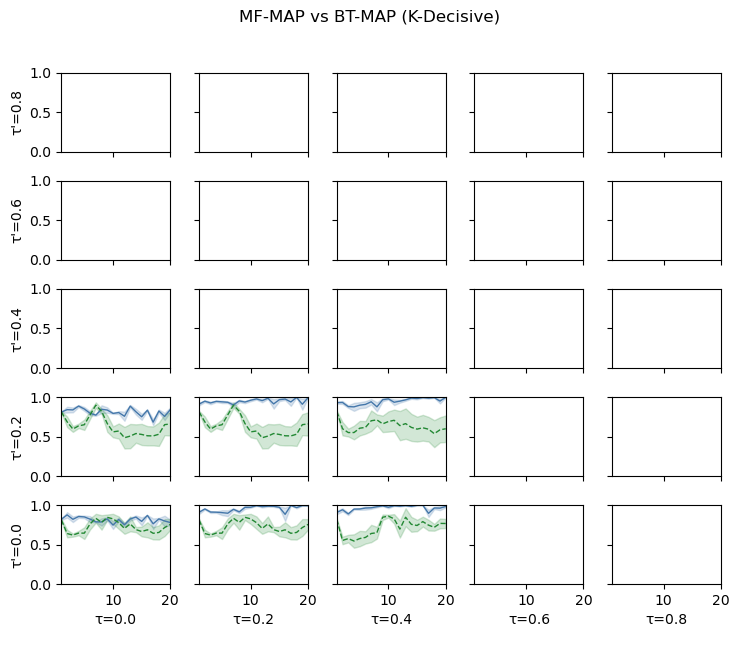

  Plotting: MF-MAP vs BT-MAP (Random FC)...
    Saved: map_convergence_grid_mf_vs_bt_map_random.pdf


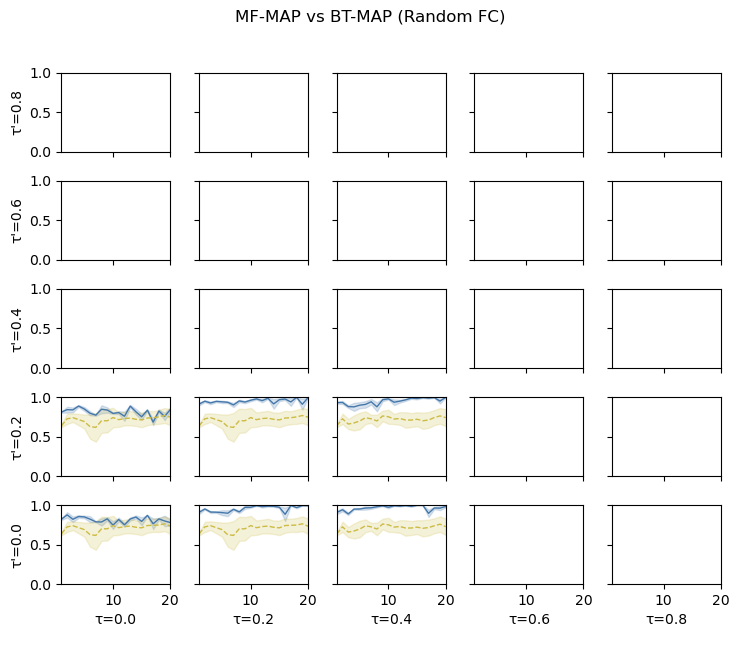

  Plotting: MF-MAP vs BT-MAP (Left FC)...
    Saved: map_convergence_grid_mf_vs_bt_map_left.pdf


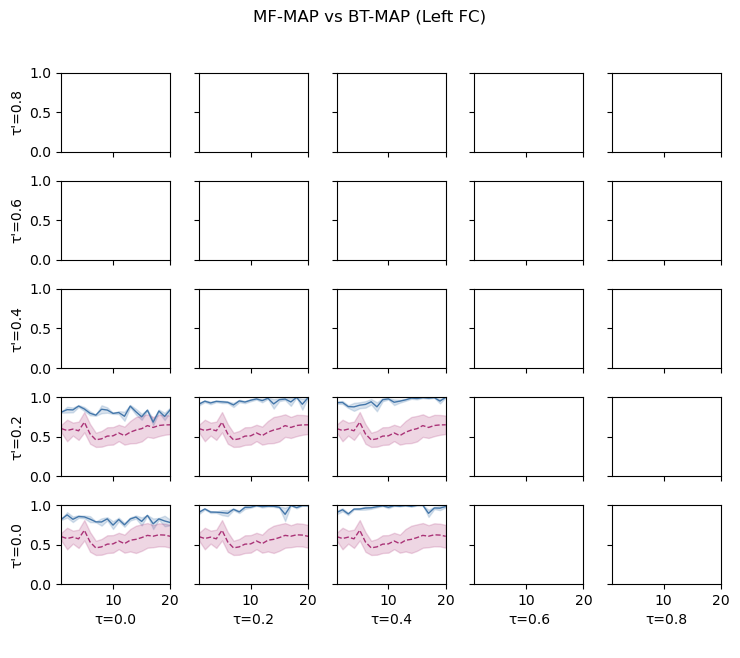

In [ ]:
plot_4_convergence_grids(
    results,
    taus=[0.0, 0.2, 0.4, 0.6, 0.8],
    tau_primes=[0.0, 0.2, 0.4, 0.6, 0.8],
    T=20,
    save_prefix='map_convergence_grid',
    show_stderr=True
)
